In [45]:
import numpy as np
import pandas as pd
from sklearn import tree

In [4]:
df = pd.read_csv("drug200.csv")
print(df.head())

   Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  drugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  drugY


In [26]:
print(df.shape)
print("-------------------------------------------------------")
#print(df.count())
#print("-------------------------------------------------------")
#print(df.value_counts())
#print("-------------------------------------------------------")
print(df.columns)
print("-------------------------------------------------------")
print(df['Sex'].value_counts())
print("-------------------------------------------------------")
print(df['BP'].value_counts())
print("-------------------------------------------------------")
print(df['Drug'].value_counts())
print("-------------------------------------------------------")
print(df['Cholesterol'].value_counts())

(200, 6)
-------------------------------------------------------
Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='str')
-------------------------------------------------------
Sex
M    104
F     96
Name: count, dtype: int64
-------------------------------------------------------
BP
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64
-------------------------------------------------------
Drug
drugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64
-------------------------------------------------------
Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64


### seperate the x and y values

In [39]:
x = df[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']].values
print(x[:5])

[[23 'F' 'HIGH' 'HIGH' 25.355]
 [47 'M' 'LOW' 'HIGH' 13.093]
 [47 'M' 'LOW' 'HIGH' 10.114]
 [28 'F' 'NORMAL' 'HIGH' 7.798]
 [61 'F' 'LOW' 'HIGH' 18.043]]


In [40]:
from sklearn import preprocessing

le_sex = preprocessing.LabelEncoder()
le_sex.fit(['F', 'M'])
x[:,1] = le_sex.transform(x[:,1])

le_bp = preprocessing.LabelEncoder()
le_bp.fit(['HIGH', 'NORMAL', 'LOW'])
x[:,2] = le_bp.transform(x[:,2])

le_ch = preprocessing.LabelEncoder()
le_ch.fit(['HIGH', 'NORMAL'])
x[:,3] = le_ch.transform(x[:,3])

print(x[:5])

[[23 0 0 0 25.355]
 [47 1 1 0 13.093]
 [47 1 1 0 10.114]
 [28 0 2 0 7.798]
 [61 0 1 0 18.043]]


In [41]:
y = df['Drug'].values
print(y[:5])

<StringArray>
['drugY', 'drugC', 'drugC', 'drugX', 'drugY']
Length: 5, dtype: str


### train and test split

In [42]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=4)

print(x_train[:5])
print(x_test[:5])
print(y_train[:5])
print(y_test[:5])

[[31 1 0 0 30.366]
 [42 0 0 0 21.036]
 [22 0 0 1 22.818]
 [59 0 1 0 10.444]
 [64 1 0 1 20.932]]
[[34 0 0 1 19.199]
 [15 0 0 1 16.725]
 [47 1 1 1 33.542]
 [73 0 0 0 18.348]
 [47 1 1 0 13.093]]
<StringArray>
['drugY', 'drugY', 'drugY', 'drugC', 'drugY']
Length: 5, dtype: str
<StringArray>
['drugY', 'drugY', 'drugY', 'drugY', 'drugC']
Length: 5, dtype: str


### training the model

In [49]:
dtc = tree.DecisionTreeClassifier(criterion='entropy', max_depth=4)
dtc.fit(x_train, y_train)

dtc

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sampl


### predicting the values and test the model

In [50]:
from sklearn.metrics import accuracy_score

y_hats = dtc.predict(x_test)
accuracy_score(y_test, y_hats)


0.95

[Text(0.625, 0.9, 'x[4] <= 14.627\nentropy = 1.923\nsamples = 160\nvalue = [17, 13, 11, 43, 76]'),
 Text(0.5, 0.7, 'x[2] <= 0.5\nentropy = 1.762\nsamples = 84\nvalue = [17, 13, 11, 43, 0]'),
 Text(0.5625, 0.8, 'True  '),
 Text(0.25, 0.5, 'x[0] <= 52.5\nentropy = 0.987\nsamples = 30\nvalue = [17, 13, 0, 0, 0]'),
 Text(0.125, 0.3, 'entropy = 0.0\nsamples = 17\nvalue = [17, 0, 0, 0, 0]'),
 Text(0.375, 0.3, 'entropy = 0.0\nsamples = 13\nvalue = [0, 13, 0, 0, 0]'),
 Text(0.75, 0.5, 'x[2] <= 1.5\nentropy = 0.729\nsamples = 54\nvalue = [0, 0, 11, 43, 0]'),
 Text(0.625, 0.3, 'x[3] <= 0.5\nentropy = 0.99\nsamples = 25\nvalue = [0.0, 0.0, 11.0, 14.0, 0.0]'),
 Text(0.5, 0.1, 'entropy = 0.0\nsamples = 11\nvalue = [0, 0, 11, 0, 0]'),
 Text(0.75, 0.1, 'entropy = 0.0\nsamples = 14\nvalue = [0, 0, 0, 14, 0]'),
 Text(0.875, 0.3, 'entropy = 0.0\nsamples = 29\nvalue = [0, 0, 0, 29, 0]'),
 Text(0.75, 0.7, 'entropy = 0.0\nsamples = 76\nvalue = [0, 0, 0, 0, 76]'),
 Text(0.6875, 0.8, '  False')]

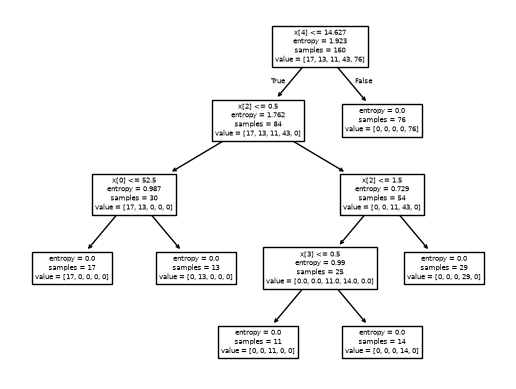

In [51]:
tree.plot_tree(dtc)